<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color='#BFD72F'>**Methodology** </font> <a class="anchor" id='top'></a> 

- [1. Introduction](#1) 
- [2. Import Libraries](#2) 
- [3. Create Metadata](#3)
- [4. Import Dataset](#4)  
- [5. Model and Assessment](#5) 
    - [5.1 Linear Regression](#5_1)
        - [5.1.1 Ordinary Least Squares (OLS)](#5_1_1)
        - [5.1.2 Ridge Regression](#5_1_2)
        - [5.1.3 Lasso Regression](#5_1_3)
        - [5.1.4 Elastic Net Regression](#5_1_4)
        - [5.1.5 Random Forest](#5_1_5)
    - [5.2 Model Comparison](#5_2)
    - [5.3 Test Models](#5_3)
- [6. Save the Results to Kaggle](#6) 
- [7. End of the Notebook](#7) 

<a class="anchor" id="1">

# **1. Introduction**

[Back to TOP](#TOP)
</a>

Here we will create models to predict the used car prices. We will create several models and later analyse their performances and choose the one that best predicts the target feature based on the MAE metric. The results here represent our final models with the thresholds and features defined in the "03_Feature_Selection" file that yield the best results we could.

<a class="anchor" id="2">

# **2. Import libraries**

[Back to TOP](#TOP)
</a>

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Finally, Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import os


from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

#KNN
from sklearn.neighbors import KNeighborsRegressor

# Random Forest
from sklearn.ensemble import RandomForestRegressor

#Neural Network
from sklearn.neural_network import MLPRegressor


#Model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

# Load Created Functions
from visualizations import *
from data_preprocessing import *
from model_and_assessment import *

# Set random seed for reproducibility
np.random.seed(40111) 

<a class="anchor" id="3">

# **3. Create Metadata**

[Back to TOP](#TOP)
</a>

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



<a class="anchor" id="4">

# **4. Import Dataset**

[Back to TOP](#top)
</a>

In this section, we load the preprocessed datasets that were previously saved after the data preprocessing steps. These datasets are ready for modelling and to get results.

In [2]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_feature_selected/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_final.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_final.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_final.csv", index_col=0)

# Load target variables and squeeze to convert DataFrame to Series since they have only one column
y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

<a class="anchor" id="5">

# **5. Model and Assessment**

[Back to TOP](#TOP)
</a>

In this notebook, we focus on training and evaluating different regression models to predict car resale prices. We start with a simple model to establish a baseline and progressively explore more complex models. The purpose of this notebook section is to create a structured workflow that allows us to train models efficiently, evaluate their performance, and compare predictions with actual values.

We also want to note that throughout this notebook we use  functions defined in our .py files, which help streamline the implementation of different models and their evaluation.

We begin by concatenating the training and validation datasets and assigning each instance a label that will later be used to create a PredefinedSplit. The purpose of this setup is to ensure that the RandomizedSearchCV uses our custom train–validation split when tuning the hyperparameters of the models we intend to evaluate.

In [3]:
# Combine train and validation datasets
X_combined = np.concatenate([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val], axis=0)

# Create a test fold index (-1 for train, 0 for validation)
test_fold = [-1] * len(X_train) + [0] * len(X_val)

print('Test fold: ', len(test_fold))
print('X_combined: ', len(X_combined))
print('y_combined: ', len(y_combined))

# Define the PredefinedSplit
ps = PredefinedSplit(test_fold=test_fold) # aqui diz que os dados de treino são os que têm label -1 e os de validação são os que têm label 0

Test fold:  75973
X_combined:  75973
y_combined:  75973


<a class="anchor" id="5_1">

## **5.1** Create a Sample to Test Models

[Back to TOP](#TOP)
</a>

In this subsection, we create a sample of our datasets to test the modelling structure and ensure that the code is correctly implemented. Working with a smaller subset speeds up experimentation and allows us to verify the functionality of our models more efficiently. This approach also helps us identify potential issues earlier in the process.

In [4]:
X_train_s = X_train.sample(1000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]
X_val_s = X_val.sample(800, random_state=42)
y_val_s = y_val.loc[X_val_s.index]

# Recriar combined sample
sample_X_combined = np.concatenate([X_train_s, X_val_s])
sample_y_combined = np.concatenate([y_train_s, y_val_s])

# Novo fold correto!
sample_test_fold = [-1] * len(X_train_s) + [0] * len(X_val_s)

ps_sample = PredefinedSplit(sample_test_fold)

<a class="anchor" id="5_2">

## **5.2** Define the Scores to Evaluate

[Back to TOP](#TOP)
</a>

In this subsection, we define the evaluation metrics that will be used to assess model performance. We create a dictionary containing the selected scoring functions, which can later be passed directly to the RandomizedSearchCV during hyperparameter tuning.

In [5]:
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}

<a class="anchor" id="5_3">

## **5.3** KNN

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_3_1">

### 5.3.1 Define Model and Grid Parameters

[Back to TOP](#TOP)
</a>

In [6]:
model_KNN = KNeighborsRegressor()
param_grid_knn = {
    "n_neighbors": [10, 20, 30, 40, 50, 80, 100],              # 3..80
    "weights": ["uniform", "distance"],
    "p": [1, 2],                                # Manhattan vs Euclidiana
    "leaf_size": [2, 5, 8, 12, 17, 25, 30, 40, 50, 60, 70, 80, 90, 100],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

<a class="anchor" id="5_3_2">

### 5.3.2 Test KNN using Samples

[Back to TOP](#TOP)
</a>

In [7]:
rsCV_KNN_sample = apply_randomized_search_cv(model_KNN, param_grid_knn, iterations= 15, scoring = scoring, refit = 'mae', 
                                             pred_split = ps_sample, X_fit = sample_X_combined, y_fit = sample_y_combined)

evaluate_model(rsCV_KNN_sample)

Fitting 1 folds for each of 15 candidates, totalling 15 fits
Train R2=0.823 | Val R2=0.792 | Train MAE=2828.9 | Val MAE=2980.3 | Gap R2=0.032 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 20, 'leaf_size': 90, 'algorithm': 'kd_tree'}
Train R2=1.000 | Val R2=0.841 | Train MAE=-0.0 | Val MAE=2668.4 | Gap R2=0.159 | Params={'weights': 'distance', 'p': 2, 'n_neighbors': 10, 'leaf_size': 70, 'algorithm': 'brute'}
Train R2=0.735 | Val R2=0.705 | Train MAE=3304.0 | Val MAE=3440.8 | Gap R2=0.030 | Params={'weights': 'uniform', 'p': 1, 'n_neighbors': 80, 'leaf_size': 8, 'algorithm': 'kd_tree'}
Train R2=0.823 | Val R2=0.792 | Train MAE=2828.9 | Val MAE=2980.3 | Gap R2=0.032 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 20, 'leaf_size': 17, 'algorithm': 'brute'}
Train R2=0.802 | Val R2=0.768 | Train MAE=2966.0 | Val MAE=3151.5 | Gap R2=0.034 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 30, 'leaf_size': 90, 'algorithm': 'kd_tree'}
Train R2=1.000 | Val R2=0.841 | Train MA

<a class="anchor" id="5_3_3">

### 5.3.3 Test KNN using the entire Dataset

[Back to TOP](#TOP)
</a>

In [8]:
rsCV_KNN = apply_randomized_search_cv(model_KNN, param_grid_knn, iterations= 15, scoring = scoring, refit = 'mae', 
                                      pred_split = ps, X_fit = X_combined, y_fit = y_combined)
evaluate_model(rsCV_KNN)

best_mae_knn = -rsCV_KNN.best_score_

Fitting 1 folds for each of 15 candidates, totalling 15 fits
Train R2=0.894 | Val R2=0.883 | Train MAE=1797.5 | Val MAE=1920.7 | Gap R2=0.011 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 20, 'leaf_size': 90, 'algorithm': 'kd_tree'}
Train R2=0.999 | Val R2=0.899 | Train MAE=33.5 | Val MAE=1754.9 | Gap R2=0.100 | Params={'weights': 'distance', 'p': 2, 'n_neighbors': 10, 'leaf_size': 70, 'algorithm': 'brute'}
Train R2=0.873 | Val R2=0.869 | Train MAE=2028.0 | Val MAE=2075.1 | Gap R2=0.003 | Params={'weights': 'uniform', 'p': 1, 'n_neighbors': 80, 'leaf_size': 8, 'algorithm': 'kd_tree'}
Train R2=0.894 | Val R2=0.883 | Train MAE=1797.6 | Val MAE=1920.9 | Gap R2=0.011 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 20, 'leaf_size': 17, 'algorithm': 'brute'}
Train R2=0.884 | Val R2=0.878 | Train MAE=1894.5 | Val MAE=1977.0 | Gap R2=0.006 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 30, 'leaf_size': 90, 'algorithm': 'kd_tree'}
Train R2=0.999 | Val R2=0.899 | Train MA

Analyzing the previous results, we observed that the models using weights='distance' displayed clear signs of overfitting. Based on this, we defined a new parameter grid that excludes this option in order to evaluate whether better and more stable results can be achieved.

In [9]:
model_KNN = KNeighborsRegressor()
param_grid_knn = {
    "n_neighbors": [10, 20, 30, 40, 50, 80, 100],              # 3..80
    "weights": ["uniform"],
    "p": [1, 2],                                # Manhattan vs Euclidiana
    "leaf_size": [2, 5, 8, 12, 17, 25, 30, 40, 50, 60, 70, 80, 90, 100],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

In [10]:
rsCV_KNN = apply_randomized_search_cv(model_KNN, param_grid_knn, iterations= 15, scoring = scoring, refit = 'mae', 
                                      pred_split = ps, X_fit = X_combined, y_fit = y_combined)

evaluate_model(rsCV_KNN)

Fitting 1 folds for each of 15 candidates, totalling 15 fits
Train R2=0.873 | Val R2=0.869 | Train MAE=2028.1 | Val MAE=2075.1 | Gap R2=0.003 | Params={'weights': 'uniform', 'p': 1, 'n_neighbors': 80, 'leaf_size': 2, 'algorithm': 'brute'}
Train R2=0.904 | Val R2=0.894 | Train MAE=1709.3 | Val MAE=1828.8 | Gap R2=0.010 | Params={'weights': 'uniform', 'p': 1, 'n_neighbors': 20, 'leaf_size': 2, 'algorithm': 'brute'}
Train R2=0.857 | Val R2=0.855 | Train MAE=2178.6 | Val MAE=2214.2 | Gap R2=0.002 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 100, 'leaf_size': 2, 'algorithm': 'ball_tree'}
Train R2=0.876 | Val R2=0.872 | Train MAE=1963.2 | Val MAE=2029.4 | Gap R2=0.004 | Params={'weights': 'uniform', 'p': 2, 'n_neighbors': 40, 'leaf_size': 12, 'algorithm': 'brute'}
Train R2=0.888 | Val R2=0.883 | Train MAE=1867.2 | Val MAE=1937.9 | Gap R2=0.004 | Params={'weights': 'uniform', 'p': 1, 'n_neighbors': 40, 'leaf_size': 90, 'algorithm': 'auto'}
Train R2=0.894 | Val R2=0.883 | Train MAE=1

In [11]:
best_mae_knn = -rsCV_KNN.best_score_
preds_knn = rsCV_KNN.best_estimator_.predict(test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


<a class="anchor" id="5_4">

## **5.4** Random Forest

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_4_1">

### 5.4.1 Define Grid Parameters

[Back to TOP](#TOP)
</a>

In [12]:
model_rf = RandomForestRegressor()

param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True]
}

<a class="anchor" id="5_4_2">

### 5.4.2 Test Random Forest using Samples

[Back to TOP](#TOP)
</a>

In [13]:
rsCV_rf_sample = apply_randomized_search_cv(model_rf, param_grid_rf, iterations= 15, scoring = scoring, refit = 'mae', 
                                      pred_split = ps_sample, X_fit = sample_X_combined, y_fit = sample_y_combined)

evaluate_model(rsCV_rf_sample)

Fitting 1 folds for each of 15 candidates, totalling 15 fits
Train R2=0.925 | Val R2=0.814 | Train MAE=1705.8 | Val MAE=2589.2 | Gap R2=0.111 | Params={'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': True}
Train R2=0.954 | Val R2=0.822 | Train MAE=1415.7 | Val MAE=2581.0 | Gap R2=0.132 | Params={'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}
Train R2=0.957 | Val R2=0.820 | Train MAE=1404.6 | Val MAE=2607.9 | Gap R2=0.136 | Params={'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}
Train R2=0.978 | Val R2=0.827 | Train MAE=914.3 | Val MAE=2538.5 | Gap R2=0.152 | Params={'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}
Train R2=0.941 | Val R2=0.811 | Train MAE=1525.0 | Val MAE=2617.4 | Gap R2=0.130 | Params={'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 1

<a class="anchor" id="5_4_3">

### 5.4.3 Test Random Forest using the entire Dataset

[Back to TOP](#TOP)
</a>

In [14]:
rsCV_rf = apply_randomized_search_cv(model_rf, param_grid_rf, iterations= 15, scoring = scoring, refit = 'mae', 
                                      pred_split = ps, X_fit = X_combined, y_fit = y_combined)

evaluate_model(rsCV_rf)

Fitting 1 folds for each of 15 candidates, totalling 15 fits


KeyboardInterrupt: 

<a class="anchor" id="5_4_4">

### 5.4.4 Apply the Best Model to the Testset
[Back to TOP](#TOP)
</a>

In [ ]:
best_model = rsCV_rf.best_estimator_
preds = best_model.predict(test)

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


<a class="anchor" id="5_5">

## **5.5** Neural Networks

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_5_1">

### 5.5.1 Define Grid Parameters

[Back to TOP](#TOP)
</a>

In [6]:
modelMLP = MLPRegressor(max_iter=500)

param_grid_mlp = {
    # Optimal architecture grid for 600k rows / 20 features
    "hidden_layer_sizes": [
        # Tier 1 — Medium models (fast, stable)
        (64,),
        (128,),
        (128, 64),
        (100, 50),

        # Tier 2 — Best performers in your tests
        (150, 100),
        (150, 100, 50),
        (200, 100),

        # Tier 3 — Larger models for marginal gains
        (200, 150, 100),
        (256, 128),
        (256, 128, 64),
    ],

    # Activation
    "activation": ["relu"],   # Best for tabular data

    # Optimizer
    "solver": ["adam"],       # Adam is far superior for MLP in sklearn

    # Regularization (L2 penalty)
    "alpha": [0.0005, 0.001, 0.002, 0.005],
    # Centered around your winning value (0.001)

    # Learning rate grid (finely tuned)
    "learning_rate_init": [0.0003, 0.0005, 0.0007, 0.001],

    # LR schedule
    "learning_rate": ["adaptive"],  # Works best with relu + large datasets

    # Batch sizes (scaling-friendly)
    "batch_size": [64, 128, 256],

    # Generalization
    "early_stopping": [True],
}


<a class="anchor" id="5_5_2">

### 5.5.2 Test Neural Networks using Samples

[Back to TOP](#TOP)
</a>

In [7]:
rsCV_mlp_sample = apply_randomized_search_cv(modelMLP, param_grid_mlp, iterations= 15, scoring = scoring, refit = 'mae', 
                                      pred_split = ps_sample, X_fit = sample_X_combined, y_fit = sample_y_combined)

evaluate_model(rsCV_mlp_sample)

Fitting 1 folds for each of 15 candidates, totalling 15 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Train R2=0.737 | Val R2=0.703 | Train MAE=3898.7 | Val MAE=3998.0 | Gap R2=0.033 | Params={'solver': 'adam', 'learning_rate_init': 0.0005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.0005, 'activation': 'relu'}
Train R2=0.743 | Val R2=0.707 | Train MAE=3863.3 | Val MAE=3976.5 | Gap R2=0.036 | Params={'solver': 'adam', 'learning_rate_init': 0.0007, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 50), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.005, 'activation': 'relu'}
Train R2=0.835 | Val R2=0.785 | Train MAE=2820.7 | Val MAE=3062.1 | Gap R2=0.050 | Params={'solver': 'adam', 'learning_rate_init': 0.0007, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.005, 'activation': 'relu'}
Train R2=0.823 | Val R2=0.775 | Train MAE=2966.5 | Val MAE=3202.9 | Gap R2=0.048 | Params={'solver': 'adam', 'learning_rate_init': 0.0005, 'learning_rat

<a class="anchor" id="5_5_3">

### 5.5.3 Test Neural Networks using the entire Dataset

[Back to TOP](#TOP)
</a>

In [8]:
rsCV_mlp = apply_randomized_search_cv(modelMLP, param_grid_mlp, iterations= 15, scoring = scoring, refit = 'mae', 
                                      pred_split = ps, X_fit = X_combined, y_fit = y_combined)

evaluate_model(rsCV_mlp)

Fitting 1 folds for each of 15 candidates, totalling 15 fits
Train R2=0.880 | Val R2=0.875 | Train MAE=1984.4 | Val MAE=2049.4 | Gap R2=0.006 | Params={'solver': 'adam', 'learning_rate_init': 0.0005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.0005, 'activation': 'relu'}
Train R2=0.877 | Val R2=0.870 | Train MAE=2050.6 | Val MAE=2105.9 | Gap R2=0.007 | Params={'solver': 'adam', 'learning_rate_init': 0.0007, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100, 50), 'early_stopping': True, 'batch_size': 128, 'alpha': 0.005, 'activation': 'relu'}
Train R2=0.885 | Val R2=0.876 | Train MAE=1954.1 | Val MAE=2037.4 | Gap R2=0.009 | Params={'solver': 'adam', 'learning_rate_init': 0.0007, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128), 'early_stopping': True, 'batch_size': 64, 'alpha': 0.005, 'activation': 'relu'}
Train R2=0.892 | Val R2=0.881 | Train MAE=1905.8 | Val MAE=1996.1 | Gap R2=0.011 | Params={

<Axes: >

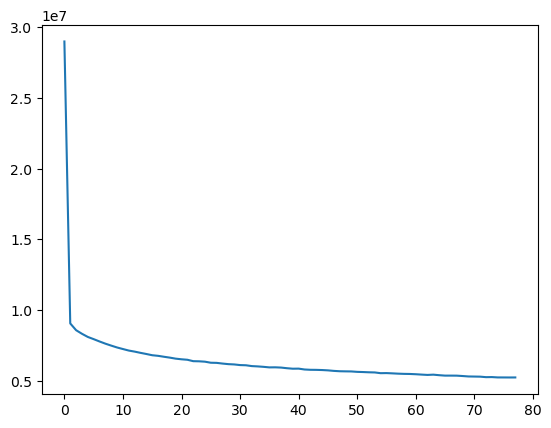

In [9]:
mlp_losses= rsCV_mlp.best_estimator_.loss_curve_
mlp_iterations= rsCV_mlp.best_estimator_.n_iter_
sns.lineplot(x=range(mlp_iterations), y=mlp_losses)

In [11]:
print(f"Total Loss: {rsCV_mlp.best_estimator_.loss_}")
print(f"Number of Iterations: {rsCV_mlp.best_estimator_.n_iter_}")
print(f"Columns: {X_train.columns.tolist()}")
print(f"Coefficients: {rsCV_mlp.best_estimator_.coefs_}")

Total Loss: 5220783.916744543
Number of Iterations: 78
Columns: ['year', 'is_automatic', 'fuel_efficiency_score', 'engineSize', 'brand_avg_engineSize', 'mileage', 'ohe_mileage_category_Very Low', 'is_recent_car', 'ohe_transmission_Semi-Auto', 'tax_efficiency', 'brand_avg_age', 'mpg', 'ohe_Brand_Opel', 'tax', 'ohe_mileage_category_Medium', 'ohe_model_ C Class', 'tax_to_engine_ratio', 'ohe_Brand_Ford', 'ohe_model_ Corsa', 'ohe_model_ Fiesta']
Coefficients: [array([[ 0.01364107,  0.43140572,  0.11682606, ...,  0.00978534,
         0.40640113, -0.46919734],
       [ 0.03191308,  0.55477996,  0.05601462, ...,  0.00455002,
         0.69746676, -0.1856777 ],
       [ 0.58354538,  0.30502049,  0.0155845 , ..., -0.05972058,
         0.94506221, -0.69839577],
       ...,
       [-0.14952298, -0.31506804, -0.24594303, ..., -0.00154424,
         0.46844715, -0.37071471],
       [-0.22269388, -0.16176761, -0.0119444 , ...,  0.02537062,
        -0.37670437, -0.71821836],
       [-0.08350707, -0.6053

<a class="anchor" id="5_6">

## **5.6** Decision Trees

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_6_1">

### 5.6.1 Define Grid Parameters

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_6_2">

### 5.6.2 Test Random Forest using Samples

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_6_3">

### 5.6.3 Test Random Forest using the entire Dataset

[Back to TOP](#TOP)
</a>

<a class="anchor" id="6">

# **6. Save results to Kaggle**

[Back to TOP](#TOP)
</a>

In [ ]:
best_mae_model = min(best_mae_knn, best_mae_rf, )

In [15]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../results/kaggle_submissions/"
os.makedirs(selected_dir, exist_ok=True)

In [31]:
# Extract carID
car_ids = test.index.values

# Create DataFrame with best model predictions
best_model_df = pd.DataFrame({
    'carID': car_ids,
    'price': preds_knn
})

# Save predictions to CSV
best_model_df.to_csv(f"{selected_dir}/predictions_knn.csv", index=False)


<a class="anchor" id="7">

# **7. End of the Notebook**

[Back to TOP](#TOP)
</a>

From the modeling and assessment stage, we developed and evaluated several predictive models to estimate car prices based on the processed features. Different algorithms were trained, and their performance was compared using appropriate evaluation metrics to identify the most effective approach. The analysis of results provided valuable insights into the model’s predictive capabilities, highlighting strengths, limitations, and potential areas for improvement. This stage represents a crucial step in validating the overall workflow and ensuring that the final model delivers accurate and reliable predictions..